In [22]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
df = pd.read_csv("/Users/fesavaskurt/Python&ML/Kodlarım/Python/datasets/ML Datasets/Student_Performance.csv")

In [3]:
df.head()

,Hours Studied,Previous Scores,Extracurricular Activities,Sleep Hours,Sample Question Papers Practiced,Performance Index
0,7,99,Yes,9,1,91.0
1,4,82,No,4,2,65.0
2,8,51,Yes,7,2,45.0
3,5,52,Yes,5,2,36.0
4,7,75,No,8,5,66.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Hours Studied                     10000 non-null  int64  
 1   Previous Scores                   10000 non-null  int64  
 2   Extracurricular Activities        10000 non-null  object 
 3   Sleep Hours                       10000 non-null  int64  
 4   Sample Question Papers Practiced  10000 non-null  int64  
 5   Performance Index                 10000 non-null  float64
dtypes: float64(1), int64(4), object(1)
memory usage: 468.9+ KB


In [6]:
X = df[["Hours Studied", "Previous Scores", "Sleep Hours", "Sample Question Papers Practiced"]]
y = df["Performance Index"]

In [9]:
df = df.drop(columns = "Extracurricular Activities")

In [11]:
df.corr()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.012390,0.001245,0.017463,0.373730
Previous Scores,-0.012390,1.000000,0.005944,0.007888,0.915189
Sleep Hours,0.001245,0.005944,1.000000,0.003990,0.048106
Sample Question Papers Practiced,0.017463,0.007888,0.003990,1.000000,0.043268
Performance Index,0.373730,0.915189,0.048106,0.043268,1.000000


<Axes: >

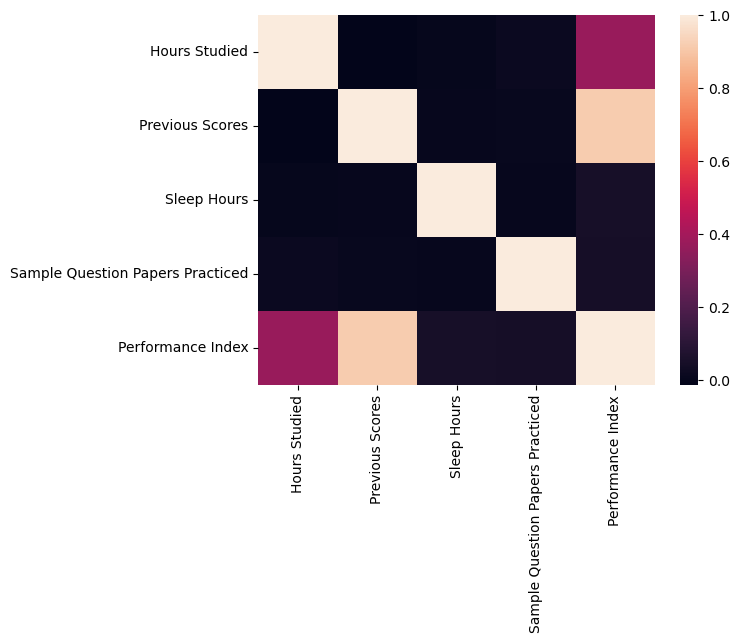

In [10]:
sns.heatmap(df.corr())

Text(0, 0.5, 'Exam Score')

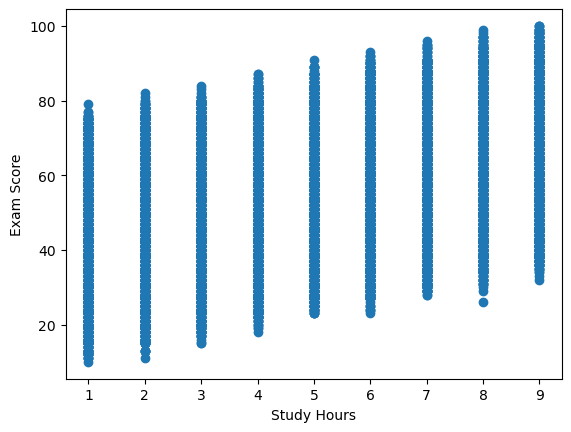

In [17]:
plt.scatter(df["Hours Studied"], df["Performance Index"])
plt.xlabel("Study Hours")
plt.ylabel("Exam Score")

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state= 42, test_size= 0.2
)

In [19]:
regression = LinearRegression()

In [20]:
regression.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [21]:
y_predict = regression.predict(X_test)

In [24]:
r2_score(y_test, y_predict)

0.9887144552384186

In [25]:
df.corr()

,Hours Studied,Previous Scores,Sleep Hours,Sample Question Papers Practiced,Performance Index
Hours Studied,1.000000,-0.012390,0.001245,0.017463,0.373730
Previous Scores,-0.012390,1.000000,0.005944,0.007888,0.915189
Sleep Hours,0.001245,0.005944,1.000000,0.003990,0.048106
Sample Question Papers Practiced,0.017463,0.007888,0.003990,1.000000,0.043268
Performance Index,0.373730,0.915189,0.048106,0.043268,1.000000


In [27]:
regression.coef_

array([2.85289351, 1.01703572, 0.47331832, 0.19172629])

In [28]:
scaler = StandardScaler()

In [29]:
X_scaler= scaler.fit_transform(X_train)
X_scaler = scaler.transform(X_test)

In [30]:
X_scaler

array([[ 0.00645547, -0.03061816,  0.85868254, -0.91452044],
       [-1.14974745, -1.35682833, -1.49649371,  1.18260268],
       [ 0.77725741, -0.78021521,  0.26988848,  0.13404112],
       ...,
       [-1.14974745, -1.7027962 ,  0.26988848, -0.91452044],
       [-0.76434648,  0.77664021,  0.26988848,  0.13404112],
       [ 0.00645547, -0.54956996,  0.85868254, -0.2154794 ]],
      shape=(2000, 4))